In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = sns.load_dataset('titanic')

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.shape

(891, 15)

In [5]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [6]:
df.drop('deck', axis=1, inplace=True)

median_age = df['age'].median()
df['age'].fillna(median_age, inplace=True)

mode_embarked = df['embarked'].mode()[0]
df['embarked'].fillna(mode_embarked, inplace=True)

mode_embark_town = df['embark_town'].mode()[0]
df['embark_town'].fillna(mode_embark_town, inplace=True)


/tmp/ipython-input-2886669766.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(median_age, inplace=True)
/tmp/ipython-input-2886669766.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

In [7]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


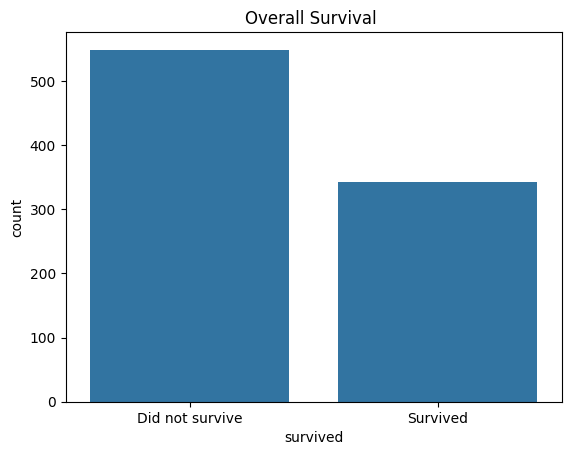

In [8]:
sns.countplot(data=df, x="survived")
plt.xticks([0, 1], ["Did not survive", "Survived"])
plt.title("Overall Survival ")
plt.show()

**Note:** Overall Survival Rate: More passengers died than survived.

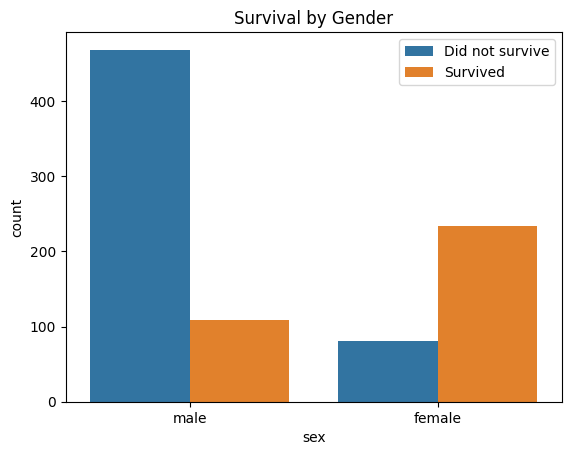

In [9]:
sns.countplot(data=df, x="sex", hue="survived")
plt.title("Survival by Gender")
plt.legend(["Did not survive", "Survived"])
plt.show()

**Note:** Survival by Gender: Women had a higher survival rate than men

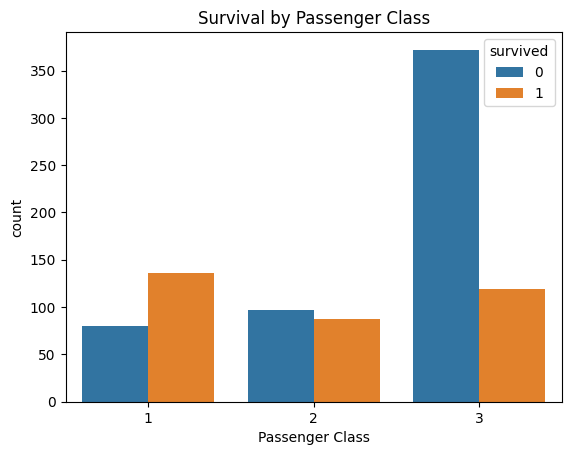

In [10]:
sns.countplot(data=df, x="pclass", hue="survived")
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.show()


**Note:** P-class 3 women had highest survival chance

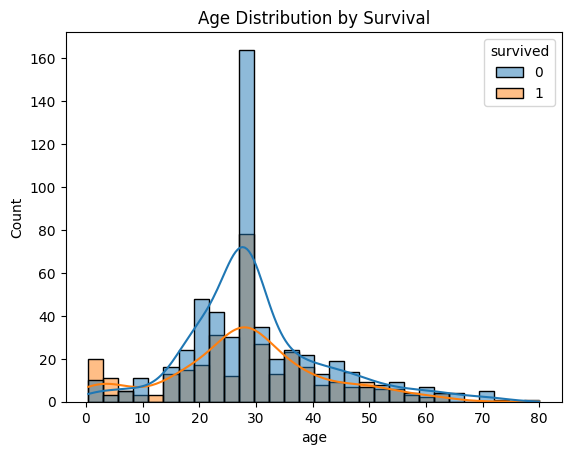

In [11]:
sns.histplot(data=df, x="age", hue="survived", bins=30, kde=True)
plt.title("Age Distribution by Survival")
plt.show()

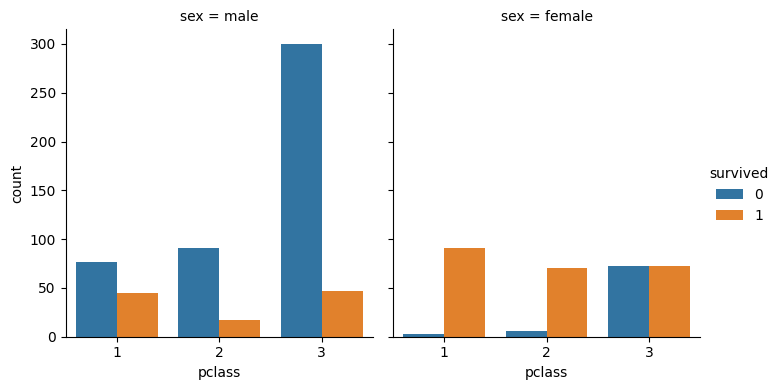

In [12]:
sns.catplot(
    data=df,
    x="pclass",
    hue="survived",
    col="sex",
    kind="count",
    height=4,
    aspect=0.9
)
plt.show()

**Note:** Value closer to 1 higher chance of survival

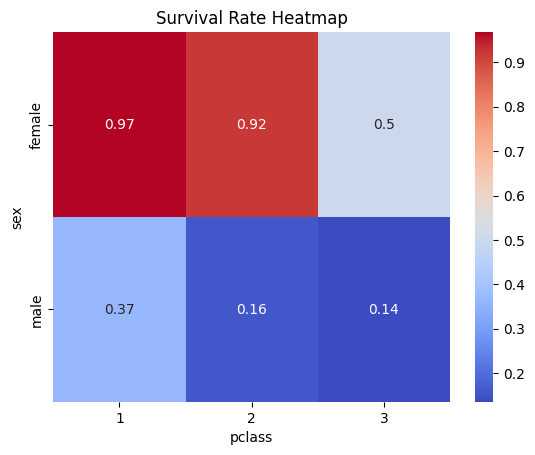

In [13]:
pivot = df.pivot_table(
    values="survived",
    index="sex",
    columns="pclass",
    aggfunc="mean"
)

sns.heatmap(pivot, annot=True, cmap="coolwarm")
plt.title("Survival Rate Heatmap")
plt.show()


**Note:** Females of pclass-1 had higher chance of survival than men of same class. Males of pclass-3 had the least chance of surival

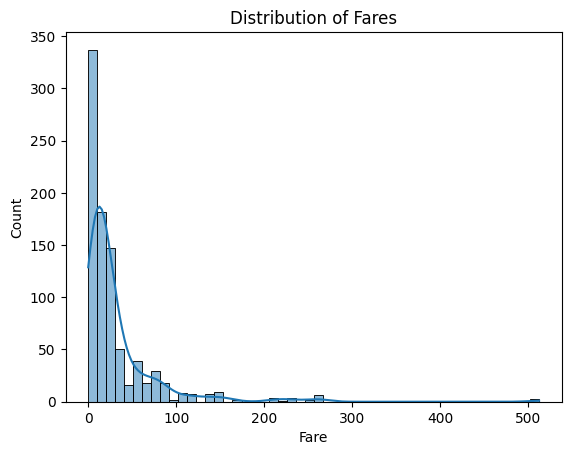

In [14]:
sns.histplot(data=df, x='fare', bins=50, kde=True)
plt.title('Distribution of Fares')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.show()

**Note:** Distribution is heavily right-skewed. most passengers paid lower fares. Few passengers who paid very high fares